In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Crear DataFrame
df = pd.DataFrame({
    "Cliente": [1, 2, 3, 4, 5, 6, 7, 8],
    "Edad": [25, 40, 35, 50, 30, 45, 38, 29],
    "Ingresos": [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    "Historial_Pagos": ["Bueno", "Regular", "Malo", "Bueno", "Regular", "Malo", "Bueno", "Regular"],
    "Categoría": ["A", "B", "C", "A", "B", "C", "A", "B"]
})

df

,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25,50000,Bueno,A
1,2,40,60000,Regular,B
2,3,35,70000,Malo,C
3,4,50,80000,Bueno,A
4,5,30,45000,Regular,B
5,6,45,85000,Malo,C
6,7,38,72000,Bueno,A
7,8,29,48000,Regular,B


In [2]:
# Ver valores nulos
print(df.isnull().sum())

# Completar valores nulos numéricos con la mediana
df.fillna(df.median(numeric_only=True), inplace=True)

# Mostrar dataset
df.head()

Cliente            0
Edad               0
Ingresos           0
Historial_Pagos    0
Categoría          0
dtype: int64


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25,50000,Bueno,A
1,2,40,60000,Regular,B
2,3,35,70000,Malo,C
3,4,50,80000,Bueno,A
4,5,30,45000,Regular,B


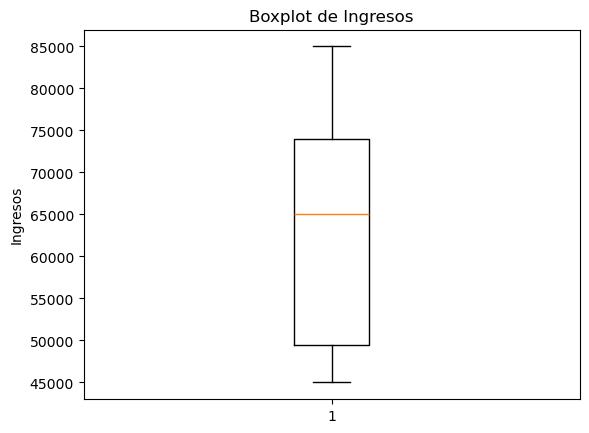

In [3]:
import matplotlib.pyplot as plt

# Boxplot de ingresos
plt.boxplot(df["Ingresos"])

plt.title("Boxplot de Ingresos")
plt.ylabel("Ingresos")

plt.show()

In [4]:
# Calcular IQR
Q1 = df["Ingresos"].quantile(0.25)
Q3 = df["Ingresos"].quantile(0.75)

IQR = Q3 - Q1

# Límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar datos
df_cleaned = df[
    (df["Ingresos"] >= limite_inferior) &
    (df["Ingresos"] <= limite_superior)
]

print("Datos originales:", len(df))
print("Datos sin outliers:", len(df_cleaned))

Datos originales: 8
Datos sin outliers: 8


In [5]:
# Normalización de ingresos
scaler_minmax = MinMaxScaler()

df_cleaned["Ingresos_Normalizado"] = scaler_minmax.fit_transform(
    df_cleaned[["Ingresos"]]
)

# Estandarización de edad
scaler_standard = StandardScaler()

df_cleaned["Edad_Estandarizada"] = scaler_standard.fit_transform(
    df_cleaned[["Edad"]]
)

df_cleaned.head()

,Cliente,Edad,Ingresos,Historial_Pagos,Categoría,Ingresos_Normalizado,Edad_Estandarizada
0,1,25,50000,Bueno,A,0.125,-1.451747
1,2,40,60000,Regular,B,0.375,0.441836
2,3,35,70000,Malo,C,0.625,-0.189358
3,4,50,80000,Bueno,A,0.875,1.704225
4,5,30,45000,Regular,B,0.000,-0.820553


In [6]:
# One-Hot Encoding
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=["Historial_Pagos"],
    prefix="Historial"
)

# Label Encoding
le = LabelEncoder()

df_cleaned["Categoria_Label"] = le.fit_transform(
    df_cleaned["Categoría"]
)

df_cleaned.head()

,Cliente,Edad,Ingresos,Categoría,Ingresos_Normalizado,Edad_Estandarizada,Historial_Bueno,Historial_Malo,Historial_Regular,Categoria_Label
0,1,25,50000,A,0.125,-1.451747,True,False,False,0
1,2,40,60000,B,0.375,0.441836,False,False,True,1
2,3,35,70000,C,0.625,-0.189358,False,True,False,2
3,4,50,80000,A,0.875,1.704225,True,False,False,0
4,5,30,45000,B,0.000,-0.820553,False,False,True,1


In [7]:
print("Dataset final transformado:")

df_cleaned.head()

Dataset final transformado:


,Cliente,Edad,Ingresos,Categoría,Ingresos_Normalizado,Edad_Estandarizada,Historial_Bueno,Historial_Malo,Historial_Regular,Categoria_Label
0,1,25,50000,A,0.125,-1.451747,True,False,False,0
1,2,40,60000,B,0.375,0.441836,False,False,True,1
2,3,35,70000,C,0.625,-0.189358,False,True,False,2
3,4,50,80000,A,0.875,1.704225,True,False,False,0
4,5,30,45000,B,0.000,-0.820553,False,False,True,1


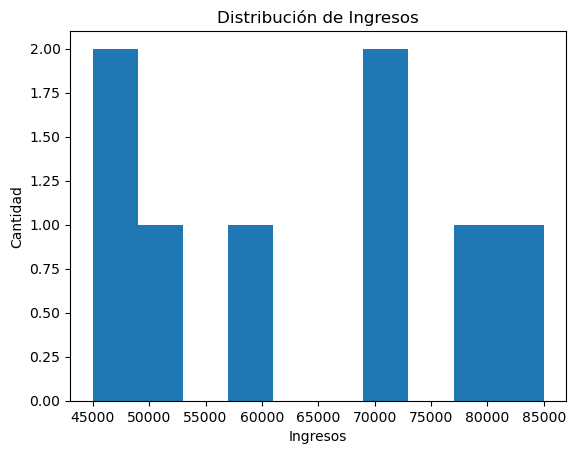

In [8]:
plt.hist(df["Ingresos"])

plt.title("Distribución de Ingresos")
plt.xlabel("Ingresos")
plt.ylabel("Cantidad")

plt.show()

Conclusión

En esta actividad realicé limpieza y transformación de datos utilizando Python. Primero revisé valores nulos y luego detecté posibles outliers en la columna de ingresos usando el método IQR.

Después apliqué normalización Min-Max y estandarización Z-score para preparar mejor los datos numéricos. También utilicé One-Hot Encoding y Label Encoding para transformar variables categóricas en valores que puedan ser utilizados por modelos de Machine Learning.

Estas técnicas ayudan a que los datos queden más organizados y preparados para futuros modelos de Machine Learning.

Además, consulté a ChatGPT sobre métodos avanzados de imputación y aprendí que herramientas como KNN Imputer pueden ser útiles cuando existen relaciones entre variables.